In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# 차트에 한글 깨지지 않도록 차트 폰트변경
plt.rcParams['font.family'] = 'Malgun Gothic'
# 차트에 "-"문자 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
data = {
    "날짜": [
        "2026-01-01", "2026-01-02", "2026-01-03", "2026-01-04", "2026-01-05",
        "2026-01-06", "2026-01-07", "2026-01-08", "2026-01-09", "2026-01-10",
        "2026-01-11", "2026-01-12", "2026-01-13", "2026-01-14", "2026-01-15"
    ],
    "판매량": [
        20, 25, 22, 30, 28,
        35, 32, 40, 38, 45,
        42, 48, 50, 46, 55
    ],
    "매출액": [
        200, 250, 220, 300, 280,
        350, 320, 400, 380, 450,
        420, 480, 500, 460, 550
    ],
    "순이익": [
        40, 50, 44, 60, 56,
        70, 64, 80, 76, 90,
        84, 96, 100, 92, 110
    ]
}

df = pd.DataFrame(data)

df.head()

,날짜,판매량,매출액,순이익
0,2026-01-01,20,200,40
1,2026-01-02,25,250,50
2,2026-01-03,22,220,44
3,2026-01-04,30,300,60
4,2026-01-05,28,280,56


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   날짜      15 non-null     str  
 1   판매량     15 non-null     int64
 2   매출액     15 non-null     int64
 3   순이익     15 non-null     int64
dtypes: int64(3), str(1)
memory usage: 612.0 bytes


In [4]:
# 시계열 데이터에서는 날짜를 문자열로 두지 않고 datetime으로 변환
df["날짜"] = pd.to_datetime(df["날짜"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      15 non-null     datetime64[us]
 1   판매량     15 non-null     int64         
 2   매출액     15 non-null     int64         
 3   순이익     15 non-null     int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 612.0 bytes


<Axes: title={'center': '날짜별 판매량'}, xlabel='날짜'>

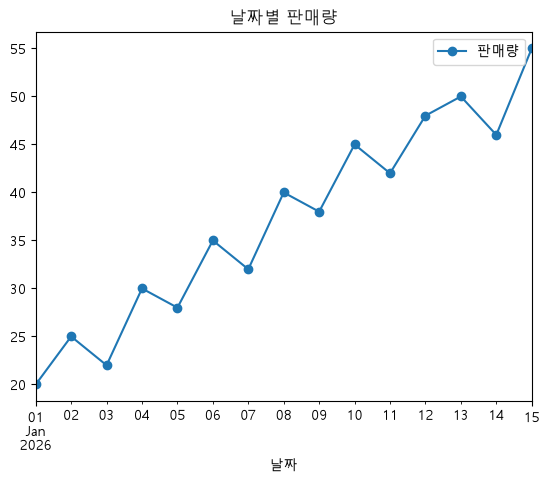

In [5]:
df.plot(
    x="날짜",
    y="판매량",
    kind="line",
    marker="o",
    title="날짜별 판매량"
)

In [6]:
import folium
data = {
    "역": [
        "강남역", "홍대입구역", "서울역", "잠실역", "역삼역",
        "신촌역", "건대입구역", "사당역", "종로3가역", "고속터미널역"
    ],
    "위도": [
        37.4979, 37.5572, 37.5547, 37.5133, 37.5006,
        37.5551, 37.5404, 37.4766, 37.5712, 37.5048
    ],
    "경도": [
        127.0276, 126.9245, 126.9707, 127.1000, 127.0366,
        126.9368, 127.0692, 126.9816, 126.9918, 127.0049
    ],
    "승하차인원": [
        180000, 150000, 140000, 125000, 110000,
        95000, 90000, 85000, 80000, 75000
    ]
}

station_df = pd.DataFrame(data)

station_df

,역,위도,경도,승하차인원
0,강남역,37.4979,127.0276,180000
1,홍대입구역,37.5572,126.9245,150000
2,서울역,37.5547,126.9707,140000
3,잠실역,37.5133,127.1000,125000
4,역삼역,37.5006,127.0366,110000
5,신촌역,37.5551,126.9368,95000
6,건대입구역,37.5404,127.0692,90000
7,사당역,37.4766,126.9816,85000
8,종로3가역,37.5712,126.9918,80000
9,고속터미널역,37.5048,127.0049,75000


In [7]:
# 지도 시각화를 위한 folium 라이브러리 불러오기
import folium

# 대한민국 서울을 중심으로 기본 지도 만들기
m = folium.Map(
    location=[37.55, 126.98],   # 지도 중심 위치: 위도, 경도
    zoom_start=11               # 지도의 확대 정도
)

# 지하철역 데이터를 한 행씩 반복
for i in range(len(station_df)):

    # 현재 행의 데이터를 row에 저장
    row = station_df.iloc[i]

    # 지도에 원(버블) 표시
    folium.CircleMarker(
        location=[
            row["위도"],          # 원을 표시할 위치의 위도
            row["경도"]           # 원을 표시할 위치의 경도
        ],

        # 승하차 인원이 많을수록 원을 크게 표시
        radius=row["승하차인원"] / 10000,

        # 원을 클릭하면 역 이름과 승하차 인원 표시
        popup=f'{row["역"]}: {row["승하차인원"]:,}명',

        # 원 내부를 채우기
        fill=True

    # 만든 원을 지도에 추가
    ).add_to(m)


# 완성된 지도를 HTML 파일로 저장
m.save("subway_map.html")

# 저장이 완료되었다는 메시지 출력
print("지도 저장 완료")

지도 저장 완료
